<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
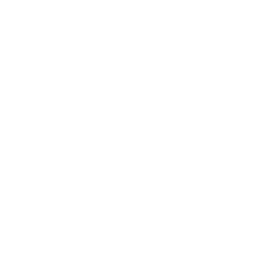
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Analys av läroplanslikhet</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Högre utbildning / Design av akademiska program &nbsp;|&nbsp; mars 2026</p>
</div>
</div>
</div>

## Sammanfattning

Denna notebook mäter läroplansöverlapp i en universitetskurskatalog
med hjälp av **PROC DISTANCE** och **METHOD=DJACCARD** — Jaccards
*olikhets*koefficient, det naturliga avståndsmåttet för binära
närvaro-/frånvarodata. Varje kurs bär 40 binära flaggor som markerar
vilka ackrediterade lärandemål den täcker, så Jaccard-avståndet
mellan två kurser är andelen täckta lärandemål som de **inte** har
gemensamt (0 = identiska målmängder, 1 = inget gemensamt mål).

Analysen körs i två delar. Först, över en katalog med 100 kurser,
profilerar den bredden på måltäckningen per institution (PROC MEANS,
PROC FREQ, ett lådagram över täckningen) och flaggar lärandemål som
**ingen** kurs på en institution täcker (täckningsluckor). För det andra
borrar den ner i en fokuserad panel med 10 kurser hämtade från de två
mest kvantitativt överlappande institutionerna — statistik och
datavetenskap — beräknar hela den parvisa Jaccard-avståndsmatrisen och
rangordnar de närmaste kursparen som kandidater för
konsolideringsgranskning. Målet är att ge en läroplanskommitté två
konkreta artefakter: en rangordnad lista över de mest lika kurserna och
en luckkarta per institution och lärandemål.

## Datakällor

| Källa | Beskrivning | Poster |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binär täckning av lärandemål per kurs (40 målflaggor) | 100 |
| WORK.PANEL10 | Konsolideringspanel för statistik + datavetenskap | 10 |

Katalogen är syntetisk. Målflaggorna dras med institutionsspecifika
sannolikheter så att disciplinerna betonar olika målkluster
(datalogi och matematik viktar de tidiga målen, laboratorievetenskaperna
viktar mittbandet), vilket ger avståndsanalysen en realistisk struktur.
Denna miljö körs utan licens, så den arbetande katalogen är begränsad
till 100 kurser.

---

In [1]:
/* --------------------------------------------------------
   Generera syntetisk kurs-lärandemålsmatris
   500 kurser x 40 ackrediterade lärandemål
   (olicensierat läge behåller de första 100)
   -------------------------------------------------------- */
data work.course_outcomes;
    CALL streaminit(42);
    FÄLT outcomes[40] lo_1 - lo_40;
    FÄLT dept_list[8] $15 _temporary_ ('DATALOGI' 'MATEMATIK' 'STATISTIK' 'TEKNIK' 'BIOLOGI' 'KEMI' 'FYSIK' 'DATAVETENSKAP');
    GÖR course_id = 1 TILL 500;
        course_label = cat('CRS', SKRIV_UT_V(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Kursnivån påverkar målens bredd */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Institutionsspecifika målkluster */
        GÖR lo = 1 TILL 40;
            base_prob = 0.15;
            /* Inst 1-2 (datalogi, matematik): betona mål 1-15 */
            OM dept_idx <= 2 AND lo <= 15 SÅ
                base_prob = 0.4 + course_level * 0.05;
            /* Inst 3-4 (statistik, teknik): betona mål 10-25 */
            ANNARS OM dept_idx IN (3, 4) AND 10 <= lo <= 25 SÅ
                base_prob = 0.35 + course_level * 0.05;
            /* Inst 5-7 (biologi, kemi, fysik): betona 20-35 */
            ANNARS OM dept_idx IN (5, 6, 7) AND 20 <= lo <= 35 SÅ
                base_prob = 0.38 + course_level * 0.04;
            /* Inst 8 (datavetenskap): bred täckning */
            ANNARS OM dept_idx = 8 SÅ
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        SLUT;
        UTDATA;
    SLUT;
    ETIKETT department = 'Institution' course_label = 'Kurs' level_code = 'Nivå';
    TA_BORT dept_idx course_level base_prob lo;
KÖR;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.83 seconds
  cpu   1.83 seconds


In [2]:
/* --------------------------------------------------------
   Generera metadata för kurskatalogen
   -------------------------------------------------------- */
data work.course_catalog;
    CALL streaminit(43);
    FÄLT dept_list[8] $15 _temporary_ ('DATALOGI' 'MATEMATIK' 'STATISTIK' 'TEKNIK' 'BIOLOGI' 'KEMI' 'FYSIK' 'DATAVETENSKAP');
    FÄLT format_list[3] $10 _temporary_ ('LECTURE' 'LAB' 'SEMINAR');
    GÖR course_id = 1 TILL 500;
        course_label = cat('CRS-', SKRIV_UT_V(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        UTDATA;
    SLUT;
    ETIKETT department = 'Institution' course_label = 'Kurs' level_code = 'Nivå';
    TA_BORT dept_idx format_idx;
    format last_offered date9.;
KÖR;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                             N
                                          Institution      Obs           Mean
                                          -----------------------------------
                                          BIOLOGI           10      0.2000000
                                          DATALOGI          13      0.3846154
                                          DATAVETENSKAP     14      0.1428571
                                          FYSIK              7      0.2857143
                                          KEMI              19      0.2105263
                                          MATEMATIK          9      0.6666667
                                          STATISTIK         11      0.0909091
                                          TEKNIK            17      0.0000000
             


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


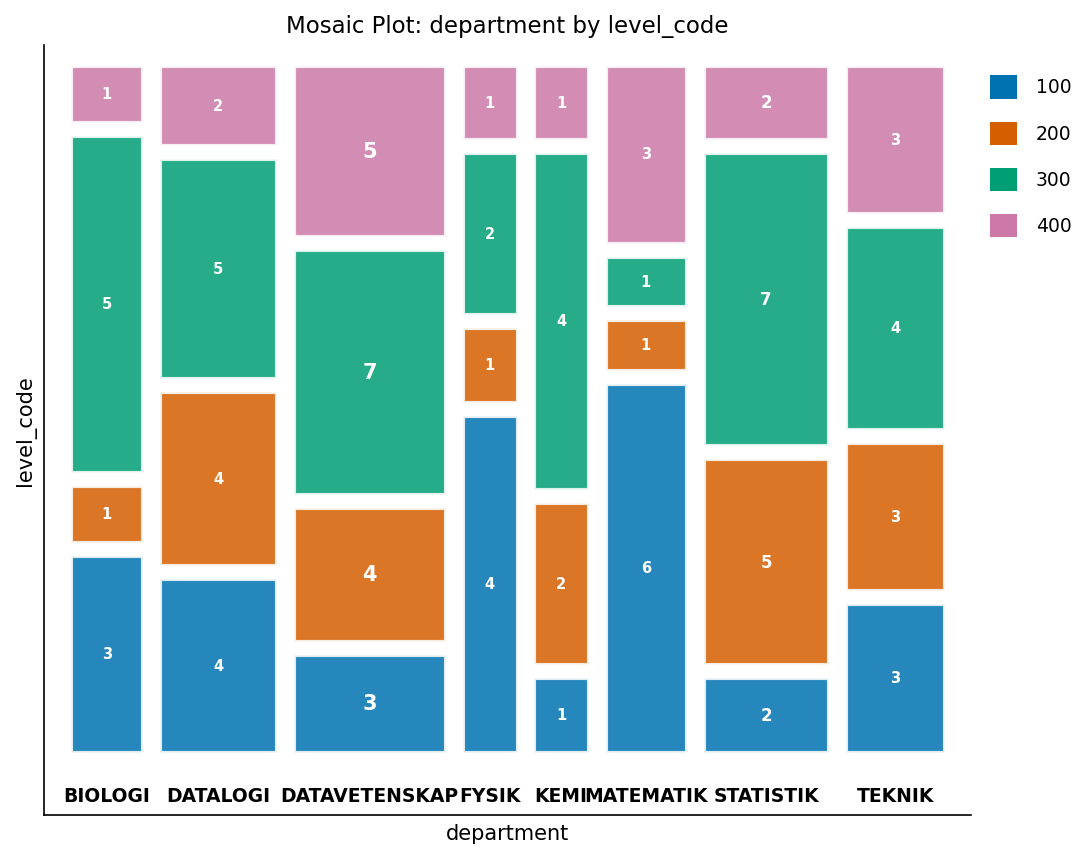

In [3]:
/* --------------------------------------------------------
   Baslinjetäckning av lärandemål per institution
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.course_outcomes mean;
    KLASS department;
    VARIABEL lo_1 - lo_40;
    ETIKETT department = 'Institution';
KÖR;

PROCEDUR FREKVENSER data=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    ETIKETT department = 'Institution' level_code = 'Nivå';
KÖR;

---


NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


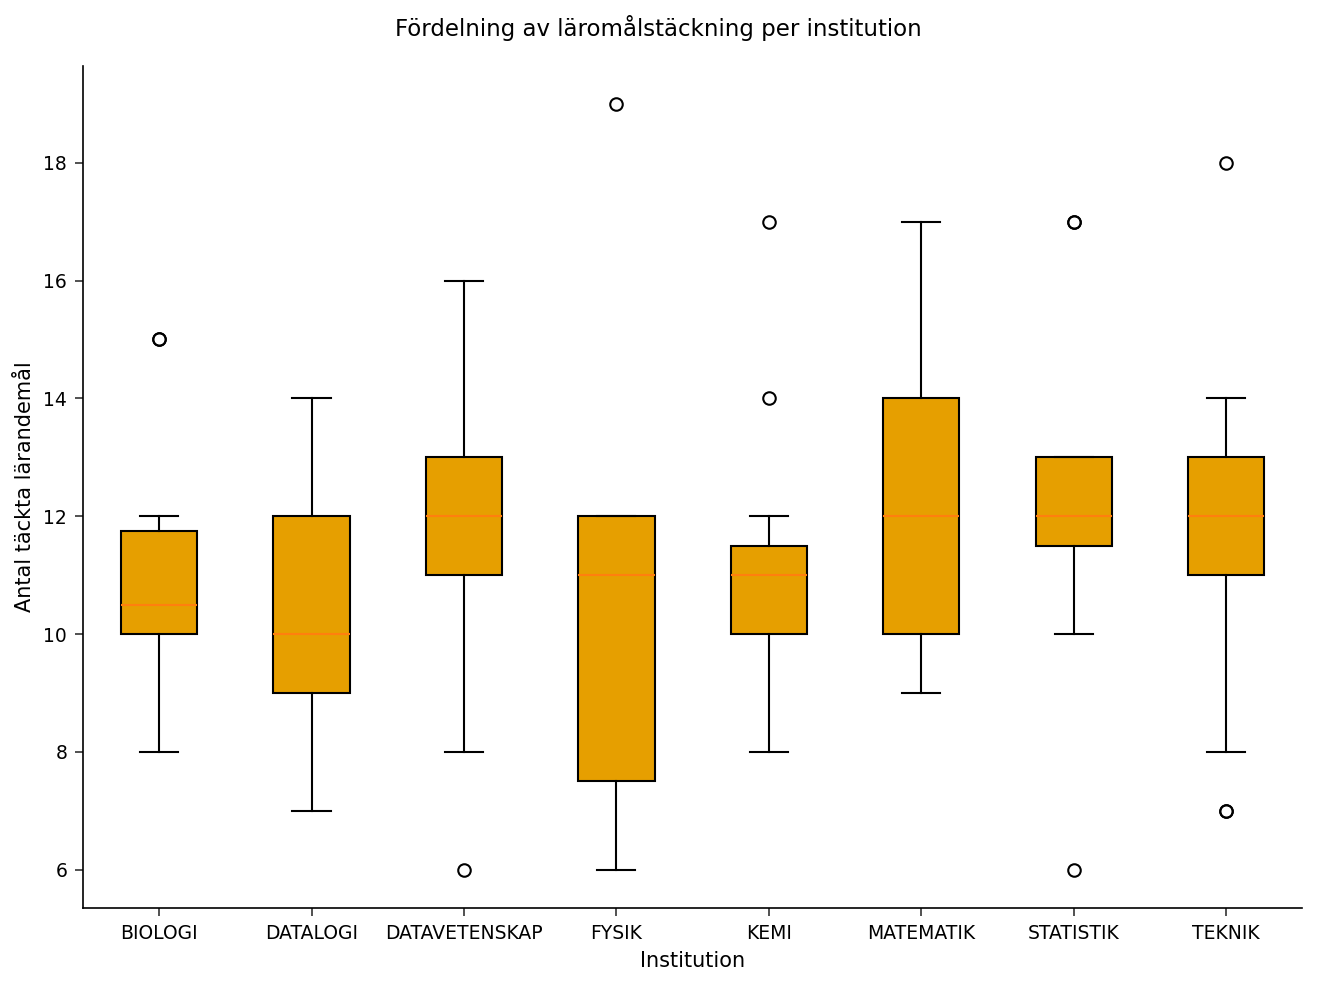

In [4]:
/* --------------------------------------------------------
   Täckningstäthet för lärandemål per institution
   -------------------------------------------------------- */
data work.outcome_counts;
    STÄLL_IN work.course_outcomes;
    FÄLT outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
    ETIKETT total_outcomes = 'Antal täckta lärandemål' department = 'Institution';
KÖR;

PROCEDUR SGPLOT data=work.outcome_counts;
    VBOX total_outcomes / category=department;
    YAXIS ETIKETT='Antal täckta lärandemål';
    XAXIS ETIKETT='Institution';
    TITEL 'Fördelning av läromålstäckning per institution';
KÖR;

---

In [5]:
/* --------------------------------------------------------
   Konsolideringspanel: de första 10 kurserna i statistik /
   datavetenskap (de två mest kvantitativt överlappande
   institutionerna). Etikettera om dem P01-P10 med en löpande
   räknare så att den kvadratiska OUT=-avståndsmatrisen får
   rena, adresserbara kolumner. Beräkna sedan hela den parvisa
   Jaccard-AVSTÅNDSmatrisen med METHOD=DJACCARD
   (0 = identiska målmängder, 1 = inget gemensamt mål).
   -------------------------------------------------------- */
data work.panel10;
    STÄLL_IN work.course_outcomes(DÄR=(department IN ('STATISTIK' 'DATAVETENSKAP')));
    BEHÅLL_VÄRDE seq 0;
    seq + 1;
    OM seq > 10 SÅ STOPPA;
    panel_id = cat('P', SKRIV_UT_V(seq, z2.));
    TA_BORT seq;
KÖR;

PROCEDUR SKRIV data=work.panel10 noobs ETIKETT;
    VARIABEL panel_id course_label department level_code;
    ETIKETT panel_id = 'Panel-ID' course_label = 'Kurs'
          department = 'Institution' level_code = 'Nivå';
    TITEL 'Konsolideringspanel: kurser i statistik och datavetenskap';
KÖR;

PROCEDUR distance data=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    VARIABEL nominal(lo_1 - lo_40);
    id panel_id;
KÖR;

PROCEDUR SKRIV data=work.panel_dist noobs;
    TITEL 'Parvis Jaccard-avståndsmatris (10 kurser)';
KÖR;

                               Konsolideringspanel: kurser i statistik och datavetenskap                                

Panel-ID     Kurs    Institution   Nivå
P01       CRS0003  DATAVETENSKAP    300
P02       CRS0006  STATISTIK        300
P03       CRS0014  DATAVETENSKAP    300
P04       CRS0015  STATISTIK        300
P05       CRS0017  STATISTIK        200
P06       CRS0019  DATAVETENSKAP    100
P07       CRS0022  STATISTIK        400
P08       CRS0033  DATAVETENSKAP    200
P09       CRS0038  STATISTIK        100
P10       CRS0040  STATISTIK        100

                               Konsolideringspanel: kurser i statistik och datavetenskap                                

                                       Parvis Jaccard-avståndsmatris (10 kurser)                                        

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09           P10
P01                0  0.8571428571  0.82608695


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Forma om den kvadratiska avståndsmatrisen till en rangordnad
   lista över kurspar. OUT=-avståndskolumnerna adresseras med en
   explicit namnlista (P01 P02 ... P10); endast den strikta övre
   triangeln (kol > rad) behålls så att varje oordnat par
   förekommer en gång och nolldiagonalen hoppas över. De fem
   närmaste paren är kandidaterna för konsolideringsgranskning.
   -------------------------------------------------------- */
data work.similar_courses;
    STÄLL_IN work.panel_dist;
    FÄLT d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    LÄNGD course_a course_b $8;
    course_a = _name_;
    row + 1;
    GÖR col = 1 TILL 10;
        OM col > row SÅ GÖR;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            UTDATA;
        SLUT;
    SLUT;
    BEHÅLL course_a course_b jaccard_dist;
    ETIKETT course_a = 'Kurs A' course_b = 'Kurs B' jaccard_dist = 'Jaccard-avstånd';
KÖR;

PROCEDUR MEDELVÄRDEN data=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    VARIABEL jaccard_dist;
    ETIKETT jaccard_dist = 'Jaccard-avstånd';
    TITEL 'Fördelning av parvisa Jaccard-avstånd (45 kurspar)';
KÖR;

PROCEDUR SORTERA data=work.similar_courses; EFTER jaccard_dist; KÖR;

data work.top_pairs;
    STÄLL_IN work.similar_courses;
    pair_rank = _n_;
    OM pair_rank <= 5;
    ETIKETT pair_rank = 'Rang';
KÖR;

PROCEDUR SKRIV data=work.top_pairs noobs ETIKETT;
    VARIABEL pair_rank course_a course_b jaccard_dist;
    ETIKETT pair_rank = 'Rang' course_a = 'Kurs A'
          course_b = 'Kurs B' jaccard_dist = 'Jaccard-avstånd';
    TITEL 'De fem närmaste kursparen (konsolideringskandidater)';
KÖR;

                                   Fördelning av parvisa Jaccard-avstånd (45 kurspar)                                   

                                                  The MEANS Procedure

 Variable      Label                   N     Minimum   Lower Quartile      Median        Mean     Maximum
 --------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard-avstånd        45       0.588            0.762       0.826       0.818       0.962
 --------------------------------------------------------------------------------------------------------

                                  De fem närmaste kursparen (konsolideringskandidater)                                  

Rang  Kurs A  Kurs B   Jaccard-avstånd
   1  P02     P10                0.588
   2  P03     P04                  0.6
   3  P03     P05                0.667
   4  P02     P04                0.684
   5  P02     P07                0.684




NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                           Otäckta lärandemål per institution                                           

                                                   The FREQ Procedure

Institution    Frequency    Percent
------------------------------------
BIOLOGI                8     26.67
DATALOGI               3     10.00
FYSIK                  8     26.67
KEMI                   2      6.67
MATEMATIK              4     13.33
STATISTIK              3     10.00
TEKNIK                 2      6.67
                                        Exempel på måluckor (de första 12 av 30)                                        

Institution     Otäckt lärandemål
BIOLOGI      LO02
BIOLOGI      LO10
BIOLOGI      LO15
BIOLOGI      LO16
BIOLOGI      LO17
BIOLOGI      LO18
BIOLOGI      LO36
BIOLOGI      LO37
DATALOGI     LO29
DATALOGI     LO35
DATALOGI     LO36
FYSIK        LO02

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


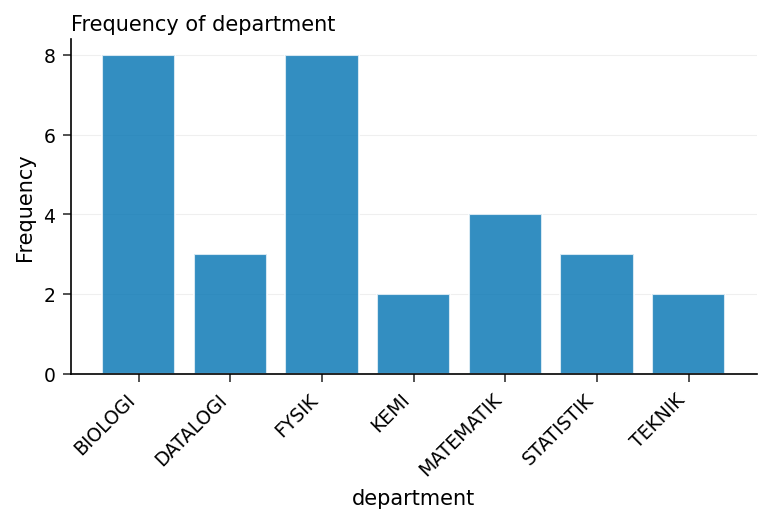

In [7]:
/* --------------------------------------------------------
   Måluckor: lärandemål som INGEN kurs på en institution
   täcker. PROC MEANS summerar varje binär målflagga inom
   institutionen; summan noll betyder att målet saknas i
   institutionens katalog.
   -------------------------------------------------------- */
PROCEDUR MEDELVÄRDEN data=work.course_outcomes sum NOPRINT;
    KLASS department;
    VARIABEL lo_1 - lo_40;
    UTDATA out=work.dept_coverage(DÄR=(_type_=1))
        sum=lo_1 - lo_40;
KÖR;

data work.outcome_gaps;
    STÄLL_IN work.dept_coverage;
    FÄLT outcomes[40] lo_1 - lo_40;
    GÖR lo = 1 TILL 40;
        outcome_id = cat('LO', SKRIV_UT_V(lo, z2.));
        courses_covering = outcomes[lo];
        OM courses_covering = 0 SÅ GÖR;
            gap_flag = 1;
            UTDATA;
        SLUT;
    SLUT;
    BEHÅLL department outcome_id courses_covering gap_flag;
    ETIKETT department = 'Institution' outcome_id = 'Otäckt lärandemål';
KÖR;

PROCEDUR FREKVENSER data=work.outcome_gaps;
    TABLES department / nocum;
    ETIKETT department = 'Institution';
    TITEL 'Otäckta lärandemål per institution';
KÖR;

PROCEDUR SKRIV data=work.outcome_gaps(obs=12) noobs ETIKETT;
    VARIABEL department outcome_id;
    ETIKETT department = 'Institution' outcome_id = 'Otäckt lärandemål';
    TITEL 'Exempel på måluckor (de första 12 av 30)';
KÖR;

---

### Tolkning

**Konsolideringspanel.** Över de 45 oordnade paren i panelen med 10
statistik- och datavetenskapskurser varierar Jaccard-avståndet från
0.588 till 0.962 med en median på 0.826 (medelvärde 0.818). Det
närmaste paret är P02 och P10 med avståndet 0.588, följt av
P03–P04 på 0.600 och P03–P05 på 0.667. Även de mest lika
kurserna skiljer sig fortfarande på ungefär 59 % av sina täckta
lärandemål, så denna katalog innehåller **inga nästan identiska kurser** —
det finns inget par som en kommitté skulle kunna slå samman rakt av.
Den rangordnade listan pekar i stället ut den handfull par som är värda
en manuell jämförelse av kursplanerna före nästa katalogcykel; paren med
störst avstånd (nära 0.962) bekräftar att statistik- och
datavetenskapskurser, trots att de delar samma institutionsgrannskap,
spänner över genuint distinkta målmängder.

**Måluckor.** Trettio luckor per institution och lärandemål framträder i
katalogen. De laboratorietunga disciplinerna bär flest: **biologi** och
**fysik** lämnar vardera 8 av de 40 ackrediteringsmålen otäckta, följt av
**matematik** (4). De kvantitativa institutionerna är bäst täckta —
**kemi** och **teknik** missar bara 2 mål vardera. Dessa luckor är de
naturliga målen för utveckling av nya kurser eller korslistning: ett mål
som saknas i en hel institution är en täckningsrisk vid
ackrediteringsförnyelse, medan konsolideringslistan tar itu med det
motsatta problemet med dubbelarbete. Tillsammans låter de två artefakterna
kommittén strama åt katalogen från båda hållen — genom att trimma bort
överlapp och fylla i ökenområden — med ett enda mängdbaserat avståndsmått.

---

In [8]:
/* --------------------------------------------------------
   Exportera de rangordnade konsolideringskandidaterna och
   institutionernas måluckekarta för läroplanskommittén.
   -------------------------------------------------------- */
PROCEDUR EXPORTERA data=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
KÖR;

PROCEDUR EXPORTERA data=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
KÖR;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Konfidentiellt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drivs av <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>